# FNO Losses

In [114]:
import numpy as np
from matplotlib.pyplot import subplots

In [138]:
# Importing the data
losses = dict()

losses["2d_241"] = np.load("outputs/losses_2d_241.npy", allow_pickle=True).item()
losses["2d_421"] = np.load("outputs/losses_2d_421.npy", allow_pickle=True).item()
losses["2d_shared_241"] = np.load("outputs/losses_2d_shared_241.npy", allow_pickle=True).item()
losses["2d_shared_421"] = np.load("outputs/losses_2d_shared_421.npy", allow_pickle=True).item()
losses["2d_uq_241"] = np.load("outputs/losses_2d_uq_241.npy", allow_pickle=True).item()
losses["2d_uq2_241"] = np.load("outputs/losses_2d_uq2_241.npy", allow_pickle=True).item()
for beta in ['0p2', '0p35', '0p7']:
    losses[f"2d_uq2_b{beta}_241"] = np.load(f"outputs/losses_2d_uq2_b{beta}_241.npy", allow_pickle=True).item()
losses["3d"] = np.load("outputs/losses_3d.npy", allow_pickle=True).item()

# Parameter counts (loaded from saved model state dicts)
from model_2d import FNO2d
from model_2d_shared import FNO2dShared
from model_2d_uq import FNO2dUQ
from model_3d import FNO3d

param_counts = {
    "2d": sum(p.numel() for p in FNO2d().parameters()),
    "2d_shared": sum(p.numel() for p in FNO2dShared().parameters()),
    "2d_uq": sum(p.numel() for p in FNO2dUQ().parameters()),
    "2d_uq2": sum(p.numel() for p in FNO2dUQ().parameters()), # same architecture
    "3d": sum(p.numel() for p in FNO3d().parameters())
}

# Initializing some keys for plotting
darcy_241 = ["2d_241", "2d_shared_241", "2d_uq_241", "2d_uq2_241"]
darcy_421 = ["2d_421", "2d_shared_421"]
uq_only = ["2d_uq_241", "2d_uq2_241", "2d_uq2_b0p2_241", "2d_uq2_b0p7_241"]

In [139]:
def make_label(key, split, param_counts, no_params=False):
    parts = key.split("_")

    if parts[0] == "2d":
        family = "2D"
        res = f"{parts[-1]}x{parts[-1]}"

        if len(parts) == 2:
            model_name = "" # Base FNO-2D
            param_key = "2d"

        elif parts[1] == "shared":
            model_name = " shared-weight"
            param_key = "2d_shared"

        elif parts[1] == "uq":
            model_name = " UQ (Gaussian NLL)"
            param_key = "2d_uq"

        elif parts[1] == "uq2":
            param_key = "2d_uq2"
            if len(parts) == 3:
                model_name = " UQ (Beta-NLL, beta=0.5)"
            else:
                beta = parts[2][1:].replace("p", ".")
                model_name = f" UQ (Beta-NLL, beta={beta})"
        else:
            model_name = ""
            param_key = "2d"

    elif parts[0] == "3d":
        family = "3D"
        model_name = "" # Base FNO-3D
        res = "64x64"
        param_key = "3d"

    else:
        return key

    if no_params:
        return f"{family}{model_name} {split} ({res})"
    else:
        return f"{family}{model_name} {split} ({res}, {param_counts[param_key]:,} params)"

def plot_loss(ax, losses, keys=None, which="test", no_params=False):
    if keys is None:
        keys = losses.keys()

    for key in keys:
        history = losses[key]
        
        if which is "both":
            for split in ["train", "test"]:
                ax.plot(history[split], label=make_label(key, split, param_counts, no_params))
        else:
            ax.plot(history[which], label=make_label(key, which, param_counts, no_params))

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Relative L2 loss")
    ax.set_yscale("log")
    ax.minorticks_on()
    ax.grid(True, which="both", alpha=0.3)
    ax.tick_params(direction="in", which="both")
    ax.legend(frameon=False)

C:\Users\Galek\AppData\Local\Temp\ipykernel_27484\216702873.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


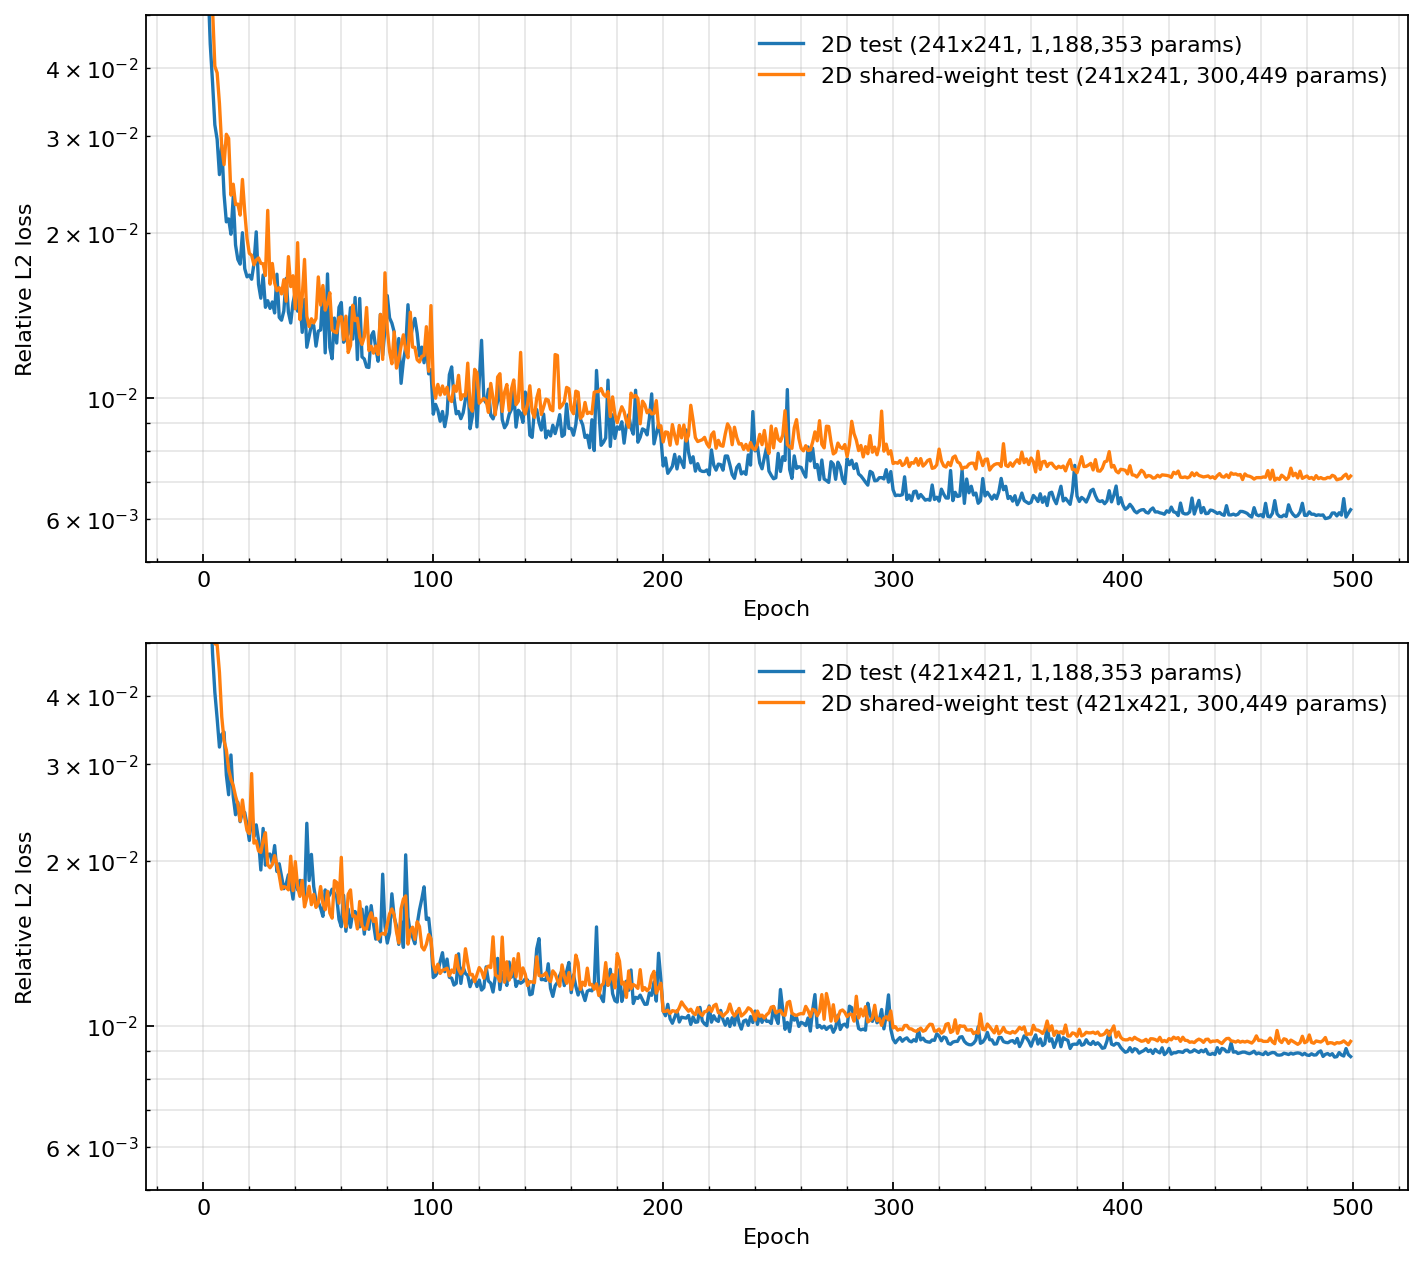

In [140]:
fig, axes = subplots(2, 1, figsize=(9, 8), dpi=160)
ax1, ax2 = axes

plot_loss(
    ax1, losses,
    keys=["2d_241", "2d_shared_241"],
    which="test"
)

plot_loss(
    ax2, losses,
    keys=["2d_421", "2d_shared_421"],
    which="test"
)

for ax in axes:
    ax.set_ylim(5e-3, .5e-1)

fig.tight_layout()
fig.show()

C:\Users\Galek\AppData\Local\Temp\ipykernel_27484\3517574603.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


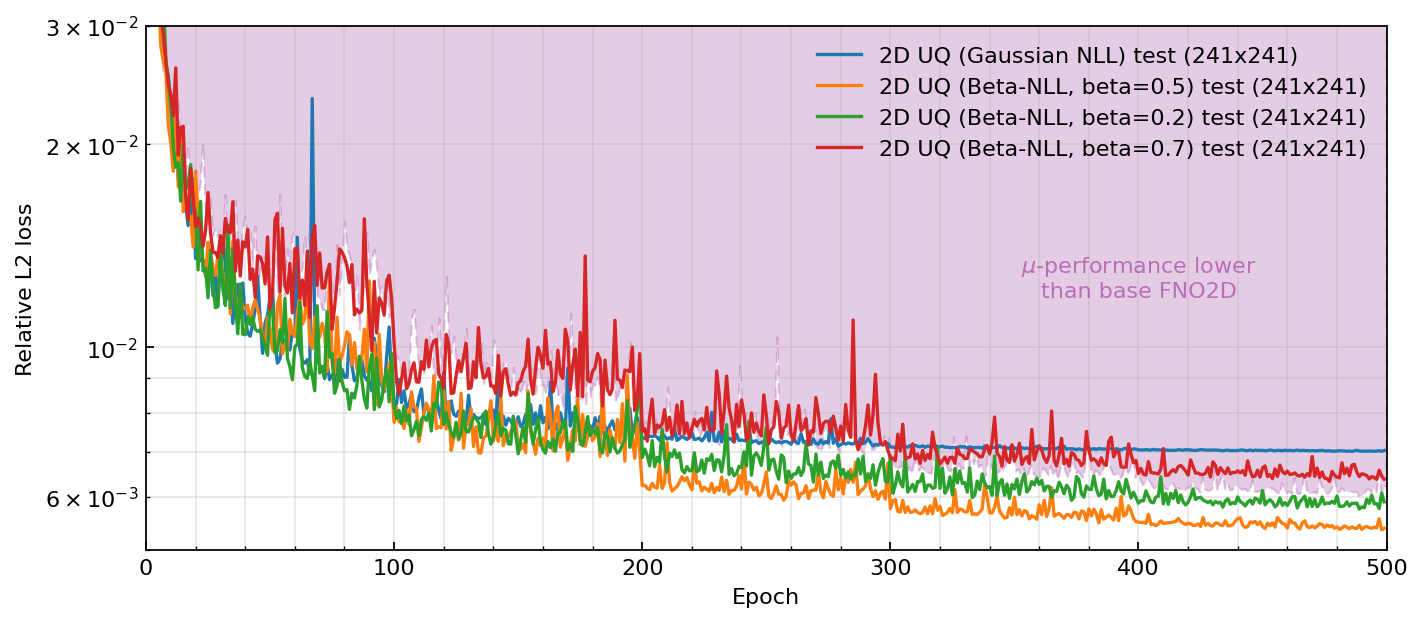

In [141]:
fig, ax = subplots(1, 1, figsize=(9, 4), dpi=160)

loss = losses["2d_241"]["test"]
ax.fill_between(np.linspace(0,500, len(loss)), .1, loss,
                alpha=0.2, ls=(1,(5,3)), color='purple')
ax.text(0.8, 0.52, transform=ax.transAxes, s='$\\mu$-performance lower\nthan base FNO2D', ha='center', va='center', fontsize=10, color='purple', alpha=0.45)

plot_loss(
    ax, losses,
    keys=uq_only,
    which="test",
    no_params=True
)

ax.set_ylim(5e-3, .3e-1)
ax.set_xlim(0,500)

fig.tight_layout()
fig.show()

C:\Users\Galek\AppData\Local\Temp\ipykernel_27484\4175069549.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


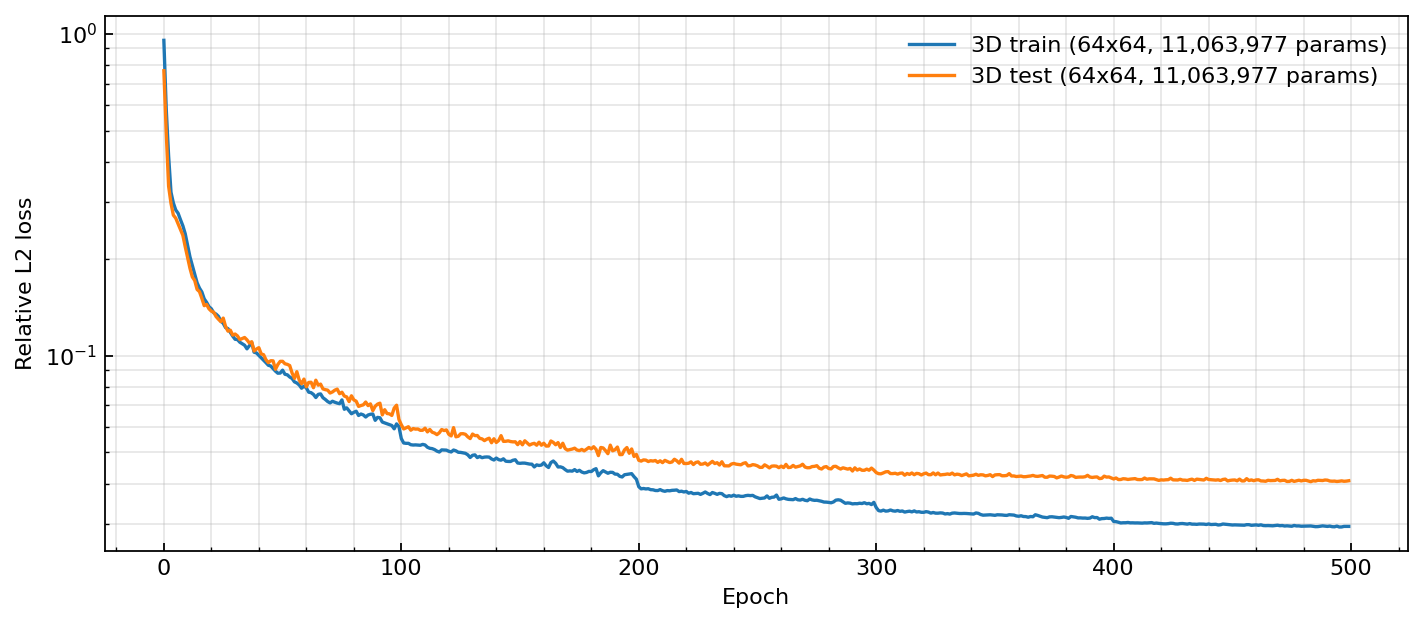

In [133]:
fig, ax = subplots(1, 1, figsize=(9, 4), dpi=160)

plot_loss(
    ax, losses,
    keys=['3d'],
    which="both"
)

# ax.set_ylim(5e-3, .3e-1)
# ax.set_xlim(0,500)

fig.tight_layout()
fig.show()